Student Performance Indicator 

Lifecycle Of Machine Learning Project 

- Understanding the Problem Statement 
- Data Collection 
- Data Checks to perform 
- Exploratory dat analysis
- Data pre-processing 
- Model Training 
- Choose best model 

1) Problem Statement 

- This project understands how the student's performance(test scores) is affected by other variables such as Gender, Ethnicity, Parental level of education, Lunch and Test preparation course. 

2) Data Collection 

- Dataset Source - https://www.kaggle.com/dataset/spsciencetist/students-performance-in-exams?datasetld=74977

- The data consists of 8 columns and 1000 rows.

2.1 Import Data and Required Packages 

Importing Pandas, Numpy, Matplotlib, Seaborn, and Warnings Library. 

In [ ]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np  
%matplotlib inline 
import warnings 
warnings.filterwarnings('ignore')

Import the CSV Data as Pandas Dataframe 

In [16]:
df = pd.read_csv('data/student.csv')

Show Top 5 Records 

In [17]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


Shape of the dataset 

In [18]:
df.shape

(1000, 8)

2.2 Dataset Information 

- gender : sex of education -> (Male/Female)
- race/ethnicity : ethnicity of students -> (Group A,B,C,D,E)
- parental education : parents' final education -> (bachelor's degree, some college, master's degree, associate's degree, high school)
- lunch : having lunch before test(standard or free/reduced)
- test preparation course: complete or not complete before test 
- math score 
- reading score 
- writing score 

3. Data Checks to perform  

- Check Missing Value 
- Check Duplicate 
- Check Data type 
- Check the number of unique values of each column
- Check statistics of data set 
- Check various categories present in the different categorical column

3.1 Check Missing Values 

In [19]:
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

There are no missing values in the dataset 

3.2 Check duplicates 

In [20]:
df.duplicated().sum()

np.int64(0)

There are no duplicate values in the dataset 

3.3 Check data types 

In [21]:
## check null and dtypes 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


3.4 Checking the number of unique values of each column

In [22]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

3.5 Check Statistics of dataset 

In [23]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


Insight 

- From above description of numerical data, all means are very close to each other - between 66 and 68.05.
- All standard deviations are also close - between 14.6 and 15.19 
- While there is a minimum score 0 for math, for writing minimum is much higher = 10 and for reading myet higher = 17  

3.7 Exploring Data 

In [26]:
print("Categories in 'gender' variable : ",end=" ")
print(df['gender'].unique())

print("Categories in 'race/ethnicity' variable : ",end=" ")
print(df['race/ethnicity'].unique())

print("Categories in 'parental level of education' variable : ",end=" ")
print(df['parental level of education'].unique())

print("Categories in 'lunch' variable : ",end=" ")
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable : ",end=" ")
print(df['test preparation course'].unique())

Categories in 'gender' variable :  ['female' 'male']
Categories in 'race/ethnicity' variable :  ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in 'parental level of education' variable :  ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' variable :  ['standard' 'free/reduced']
Categories in 'test preparation course' variable :  ['none' 'completed']


In [28]:
## define numerical & categorical columns 
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'object']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'object']

# print columns 
print('We have {} numeric features: {}'.format(len(numeric_features),numeric_features))
print('\n We have {} categorical features: {}'.format(len(categorical_features),categorical_features))

We have 3 numeric features: ['math score', 'reading score', 'writing score']

 We have 5 categorical features: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


3.8 Adding columns for "Total Score" and "Average"

In [30]:
df['total score'] = df['math score'] + df['reading score'] + df['writing score']
df['average'] = df['total score']/3
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [36]:
reading_full = df[df['reading score'] == 100]['average'].count()
writing_full = df[df['writing score'] == 100]['average'].count()
math_full = df[df['math score'] == 100]['average'].count()

print(f"Number of students with full marks in maths:{math_full}")
print(f"Number of students with full marks in writing:{writing_full}")
print(f"Number of students with full marks in reading:{reading_full}")

Number of students with full marks in maths:7
Number of students with full marks in writing:14
Number of students with full marks in reading:17


In [37]:
reading_less_20 = df[df['reading score']<=20]['average'].count()
writing_less_20 = df[df['writing score']<=20]['average'].count()
math_less_20 = df[df['math score']<=20]['average'].count()

print(f"Number of students with full marks in reading:{reading_less_20}")
print(f"Number of students with full marks in writing:{writing_less_20}")
print(f"Number of students with full marks in maths:{math_less_20}")

Number of students with full marks in reading:1
Number of students with full marks in writing:3
Number of students with full marks in maths:4


Insights 

- From above values we get students have performed the worst in maths 
- Best performance in reading section 

4. Exploring Data (Visualization)

4.1 Visualize average score distribution to make some conclusion 

- Histogram 
- Kernel Distribution Function(KDE)

4.1 Histogram & KDE

<Axes: xlabel='average', ylabel='Count'>

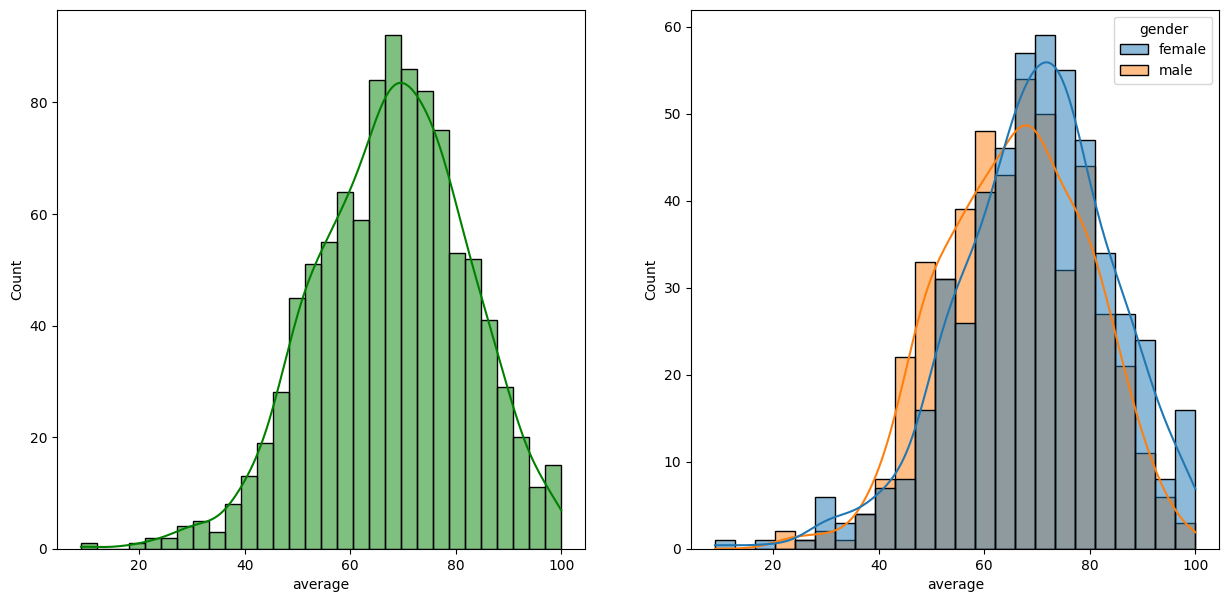

In [39]:
fig, axs = plt.subplots(1,2, figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df, x='average',bins=30, kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df, x='average',kde=True,hue='gender')

Insights 

- Female students tend to perform well then male students 

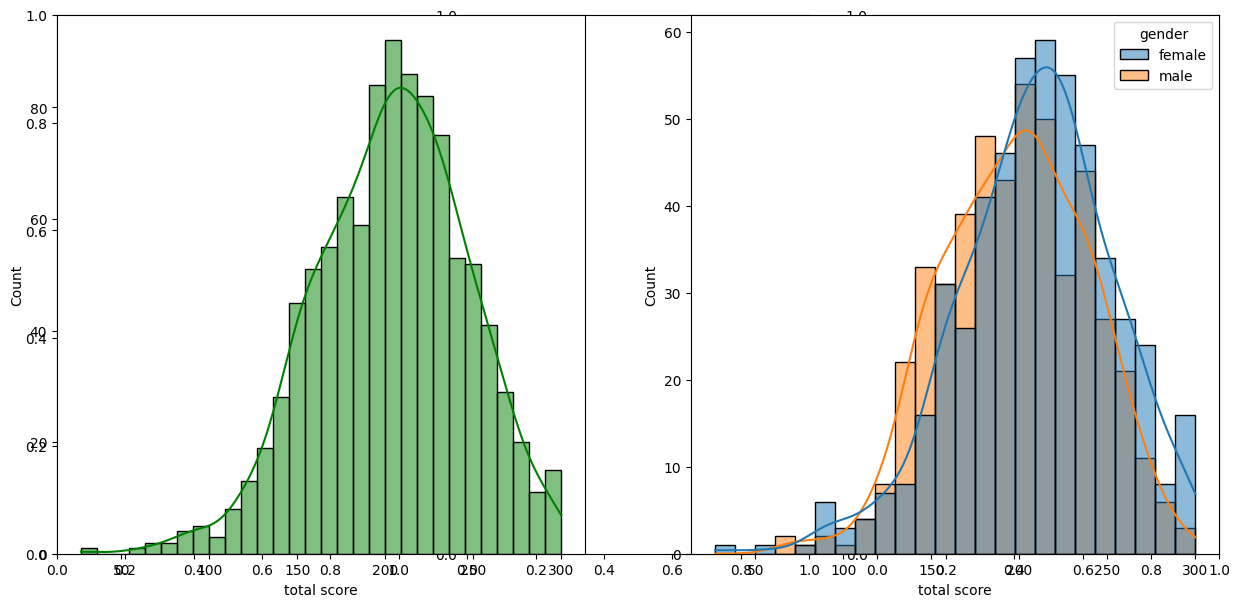

In [41]:
plt.subplots(1,3,figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df, x='total score',bins=30, kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df, x='total score',kde=True,hue='gender')
plt.show()

Insights 

- Female students tend to perform well then male students 

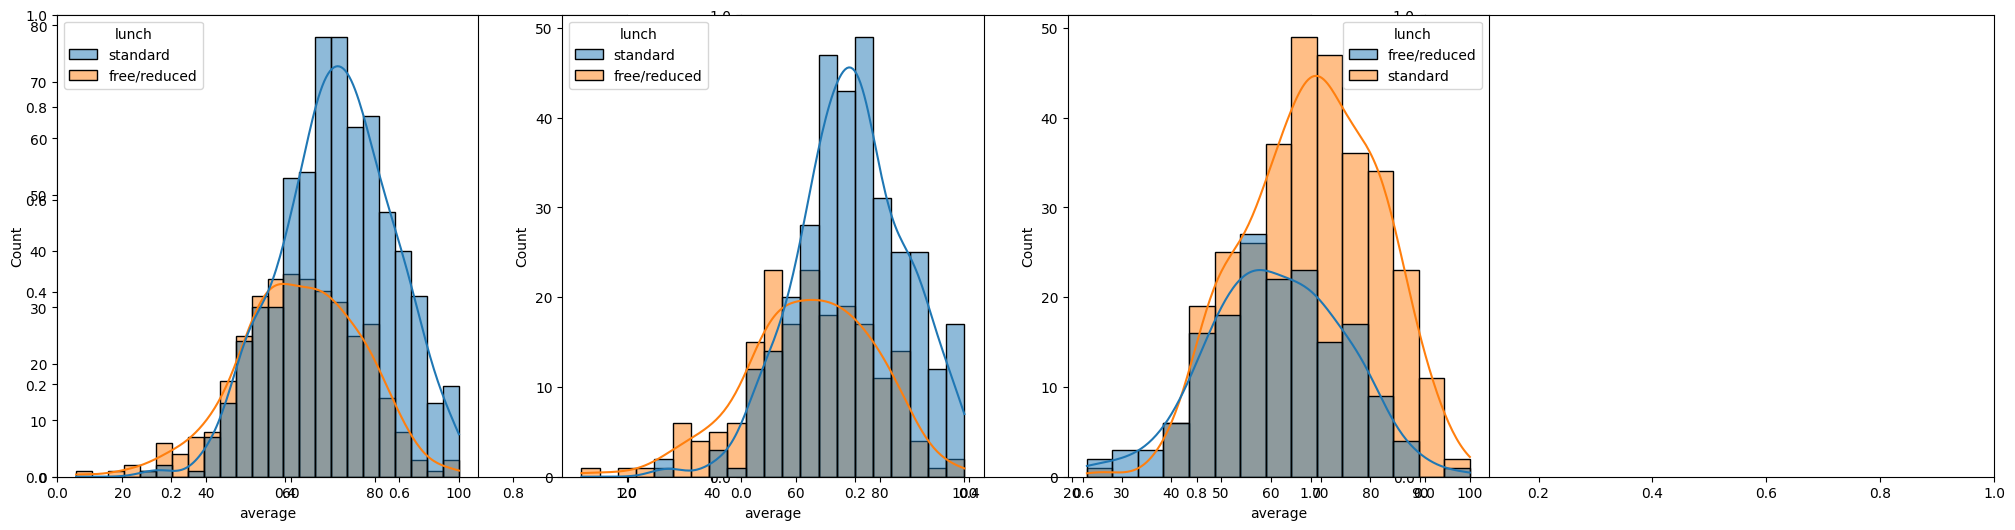

In [42]:
plt.subplots(1,3, figsize=(25,6))
plt.subplot(141)
sns.histplot(data=df, x='average',kde=True,hue='lunch')
plt.subplot(142)
sns.histplot(data=df[df.gender=='female'],x='average',kde=True,hue='lunch')
plt.subplot(143)
sns.histplot(data=df[df.gender=='male'],x='average',kde=True,hue='lunch')
plt.show()

Insights 

- Standard lunch helps perform well in exams.
- Standard lunch helps perform well in exams be it a male or a female.

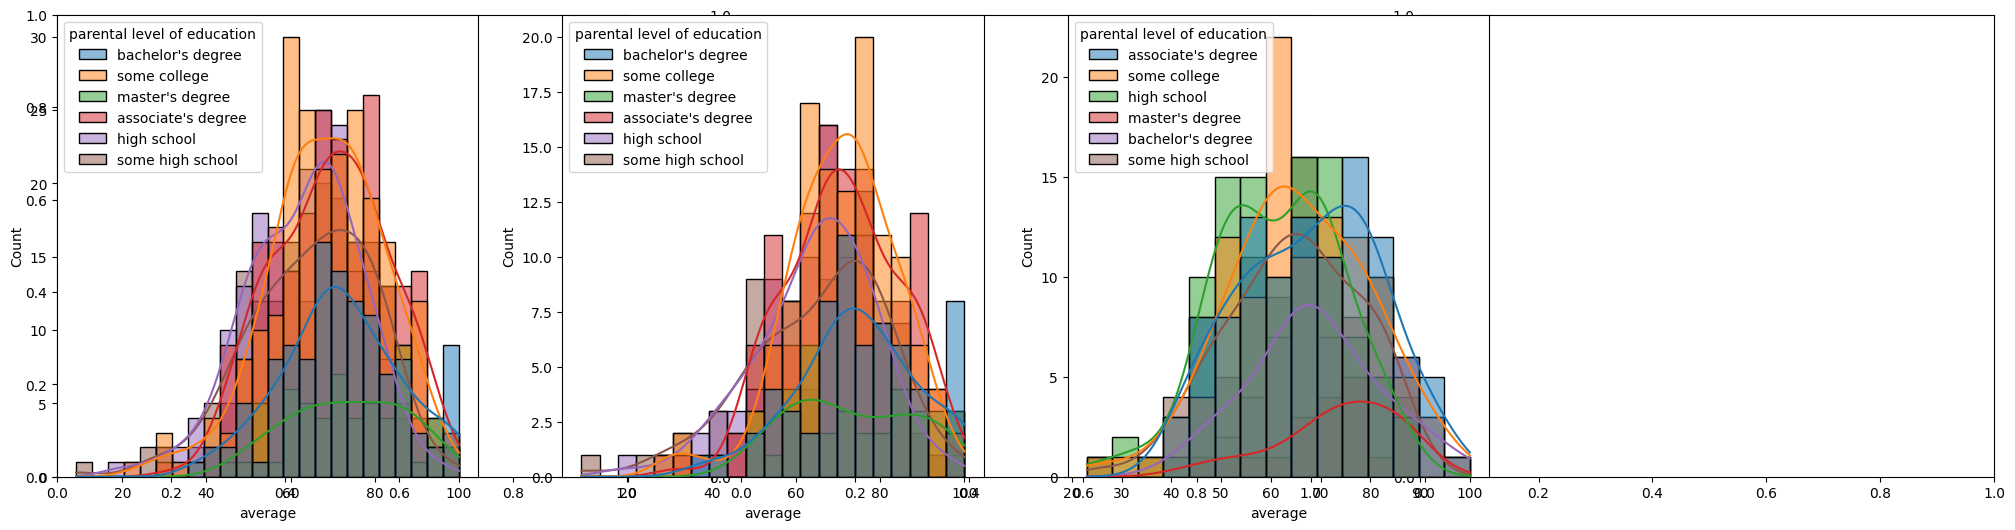

In [43]:
plt.subplots(1,3, figsize=(25,6))
plt.subplot(141)
sns.histplot(data=df, x='average',kde=True,hue='parental level of education')
plt.subplot(142)
sns.histplot(data=df[df.gender=='female'],x='average',kde=True,hue='parental level of education')
plt.subplot(143)
sns.histplot(data=df[df.gender=='male'],x='average',kde=True,hue='parental level of education')
plt.show()

Insights 

- In general parental's education don't help student perform well in exam. 
- 2nd plot shows that parent's whose education is of associate's degree or master's degree their male child tend to perform well in exam
- 3rd plot we can see there is no effect of parental's education on female students.

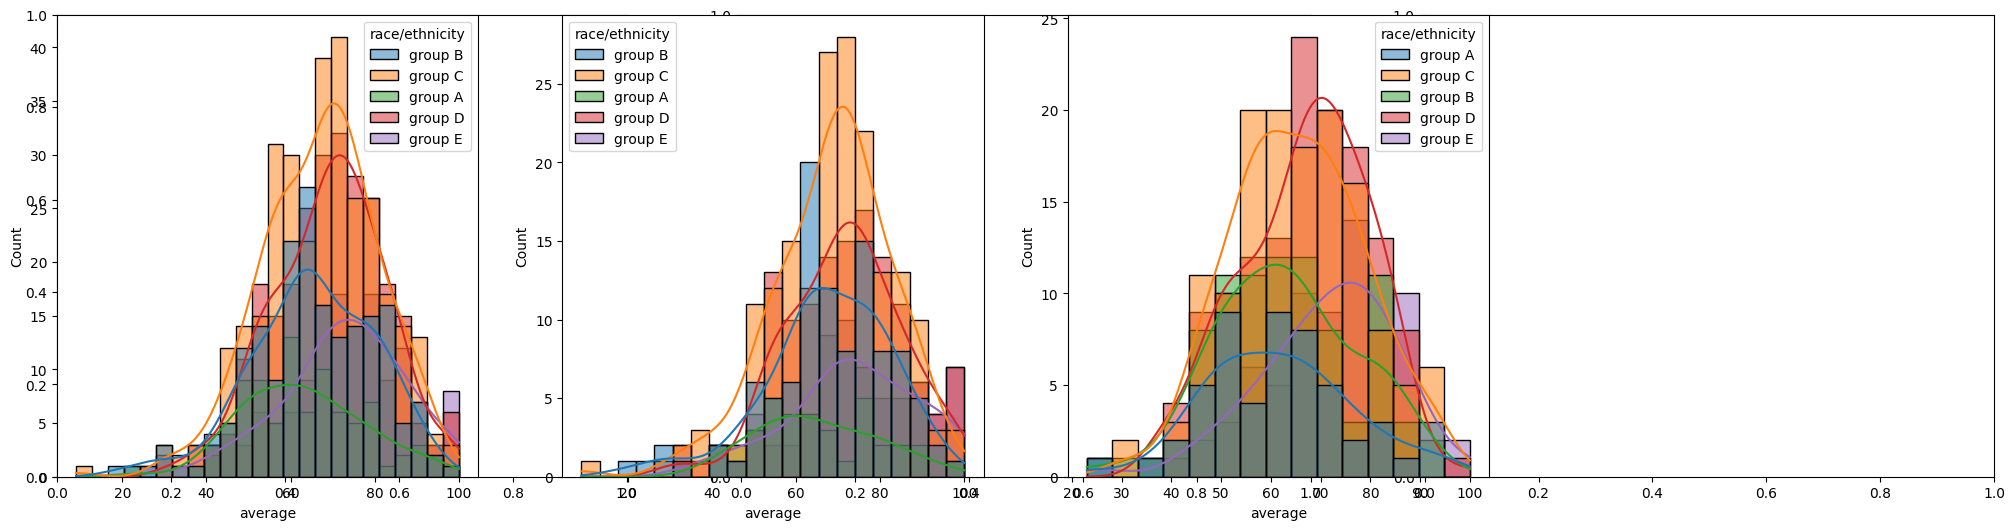

In [44]:
plt.subplots(1,3, figsize=(25,6))
plt.subplot(141)
sns.histplot(data=df, x='average',kde=True,hue='race/ethnicity')
plt.subplot(142)
sns.histplot(data=df[df.gender=='female'],x='average',kde=True,hue='race/ethnicity')
plt.subplot(143)
sns.histplot(data=df[df.gender=='male'],x='average',kde=True,hue='race/ethnicity')
plt.show()